<a href="https://colab.research.google.com/github/VBraghittoni/Ballistic-launch-and-linear-systems/blob/main/benfords_law.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(10,12)})

In [ ]:
import requests
import json
import time
import pandas as pd
from datetime import datetime
import math
import sys

# ==================== CONFIGURATION ====================
BASE_URL = "https://pncp.gov.br/api/consulta"

# Example: Pregão Eletrônico from the last 7 days
DATA_INICIAL = "20260325"          # YYYYMMDD
DATA_FINAL   = datetime.now().strftime("%Y%m%d")
CODIGO_MODALIDADE = 8              # 8 = Pregão Eletrônico
UF = None                          # e.g. "SP" or None
CODIGO_MUNICIPIO_IBGE = None
CNPJ_ORGAO = None

PAGINA_INICIAL = 1
TAMANHO_PAGINA = 50
DELAY_BETWEEN_PAGES = 0.5

OUTPUT_JSON = "licitacoes_pncp.json"
OUTPUT_CSV  = "licitacoes_pncp.csv"
# ======================================================

def get_leading_digit(value):
    """Return the leading significant digit (1-9) for Benford's Law"""
    if value is None or value <= 0:
        return None
    try:
        # Robust method using logarithm (handles very large/small floats)
        log = math.log10(abs(float(value)))
        frac = log - math.floor(log)
        digit = int(10 ** frac)               # gives 1 to 9
        return digit
    except (ValueError, TypeError):
        return None

def fetch_contratacoes(page):
    params = {
        "dataInicial": DATA_INICIAL,
        "dataFinal": DATA_FINAL,
        "codigoModalidadeContratacao": CODIGO_MODALIDADE,
        "pagina": page,
        "tamanhoPagina": TAMANHO_PAGINA,
    }
    if UF:
        params["uf"] = UF
    if CODIGO_MUNICIPIO_IBGE:
        params["codigoMunicipioIbge"] = CODIGO_MUNICIPIO_IBGE
    if CNPJ_ORGAO:
        params["cnpj"] = CNPJ_ORGAO

    url = f"{BASE_URL}/v1/contratacoes/publicacao"
    response = requests.get(url, params=params, timeout=30)

    if response.status_code != 200:
        print(f"❌ Error {response.status_code} on page {page}: {response.text}")
        return None

    return response.json()


#Main
all_contratacoes = []
page = PAGINA_INICIAL
total_pages = None

print(f"🔍 Fetching licitações from {DATA_INICIAL} to {DATA_FINAL}...\n")

while True:
    print(f"📄 Page {page}...", end=" ")
    data = fetch_contratacoes(page)

    if not data or "data" not in data:
        print("No more data.")
        break

    page_data = data.get("data", [])
    all_contratacoes.extend(page_data)

    total_pages = data.get("totalPages", 1)
    print(f"✅ {len(page_data)} records (total pages: {total_pages})")

    if page >= total_pages:
        break

    page += 1
    time.sleep(DELAY_BETWEEN_PAGES)

print(f"\n🎉 Total records retrieved: {len(all_contratacoes)}")

# 1. Save raw JSON
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    #json.dump(all_contratacoes, f, ensure_ascii=False, indent=2)
    print(f"💾 Full JSON saved to {OUTPUT_JSON}")

# 2. Convert to CSV (flattened)
if all_contratacoes:
    df = pd.json_normalize(all_contratacoes)
    #df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
    print(f"📊 CSV saved to {OUTPUT_CSV} ({len(df)} rows)")

# ===================== BENFORD'S LAW SECTION =====================
leading_digits_estimado = []
leading_digits_homologado = []

for record in all_contratacoes:
    # Metric 1
    digit_est = get_leading_digit(record.get("valorTotalEstimado"))
    if digit_est is not None:
        leading_digits_estimado.append(digit_est)

    # Metric 2
    digit_hom = get_leading_digit(record.get("valorTotalHomologado"))
    if digit_hom is not None:
        leading_digits_homologado.append(digit_hom)

print("\n📈 BENFORD'S LAW – Leading digits extracted:")
print(f"   • valorTotalEstimado   → {len(leading_digits_estimado):,} digits stored")
print(f"   • valorTotalHomologado → {len(leading_digits_homologado):,} digits stored")

# Optional: quick frequency preview
for name, digits_list in [("Estimado", leading_digits_estimado),
                          ("Homologado", leading_digits_homologado)]:
    if digits_list:
        counts = pd.Series(digits_list).value_counts().sort_index()
        print(f"\n   {name} digit distribution:")
        for d in range(1, 10):
            print(f"      {d}: {counts.get(d, 0)} times")

🔍 Fetching licitações from 20260325 to 20260401...

📄 Page 1... ✅ 50 records (total pages: 1)

🎉 Total records retrieved: 50
💾 Full JSON saved to licitacoes_pncp.json
📊 CSV saved to licitacoes_pncp.csv (50 rows)

📈 BENFORD'S LAW – Leading digits extracted:
   • valorTotalEstimado   → 47 digits stored
   • valorTotalHomologado → 25 digits stored

   Estimado digit distribution:
      1: 16 times
      2: 6 times
      3: 6 times
      4: 5 times
      5: 3 times
      6: 6 times
      7: 3 times
      8: 1 times
      9: 1 times

   Homologado digit distribution:
      1: 11 times
      2: 3 times
      3: 3 times
      4: 1 times
      5: 0 times
      6: 4 times
      7: 1 times
      8: 2 times
      9: 0 times


In [ ]:
digit_counts_estimado = {}
total_estimados = len(leading_digits_estimado)
for x in leading_digits_estimado:
    digit_counts_estimado[x] = digit_counts_estimado.get(x, 0) + 1
digit_proportions_estimado = {k: v / len(leading_digits_estimado) for k, v in digit_counts_estimado.items()}

digit_counts_homologado = {}
total_homologados = len(leading_digits_homologado)
for x in leading_digits_homologado:
    digit_counts_homologado[x] = digit_counts_homologado.get(x, 0) + 1
digit_proportions_homologado = {k: v / len(leading_digits_homologado) for k, v in digit_counts_homologado.items()}

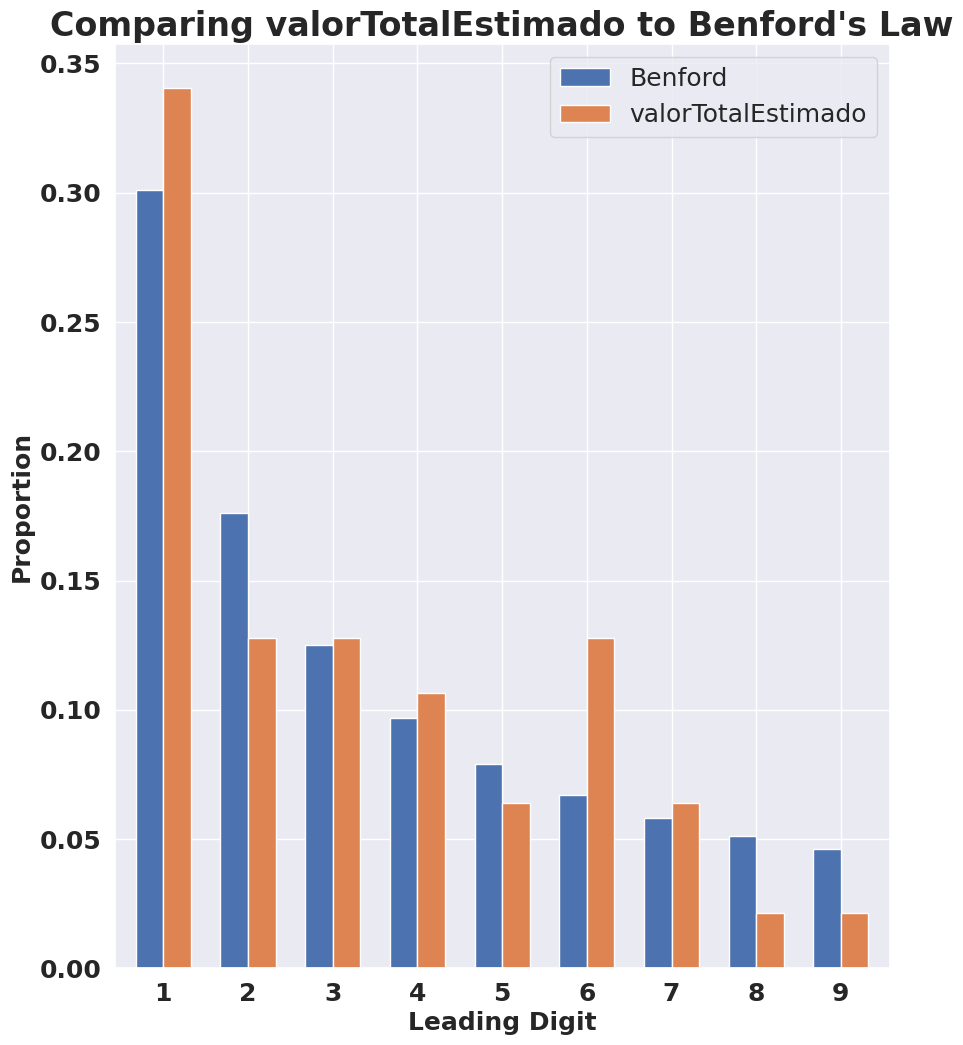

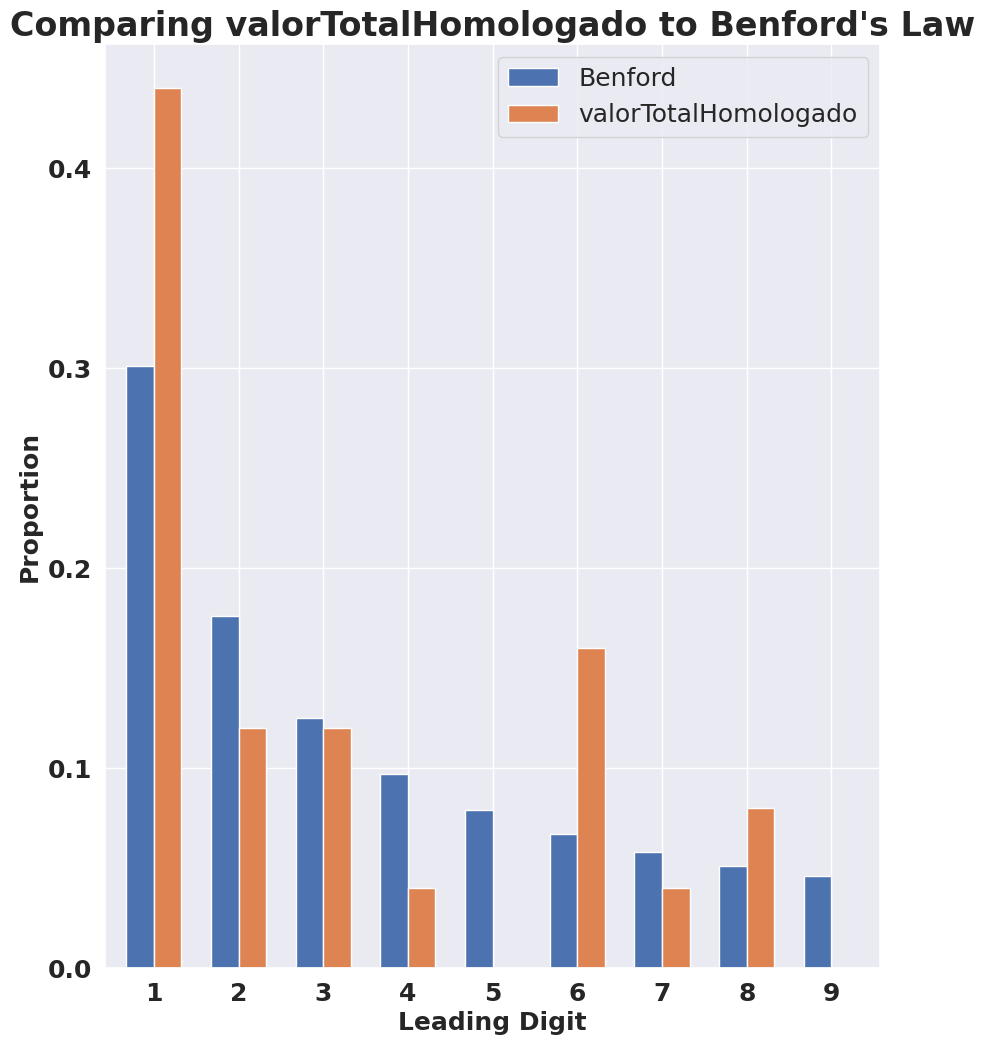

In [ ]:
ideal_benford = [.301, .176, .125, .097, .079, .067, .058, .051, .046]
benford_df = pd.DataFrame({"Leading Digit": ['1', '2', '3', '4', '5', '6', '7', '8', '9'], "Proportion": ideal_benford, "Distribution": "Benford"})

# Combine the individual digit proportion dictionaries into a single dictionary for iteration
all_digit_proportions_for_plot = {
    "valorTotalEstimado": digit_proportions_estimado,
    "valorTotalHomologado": digit_proportions_homologado
}

# Iterate through both estimated and homologated proportions
for name, digit_proportions_dict in all_digit_proportions_for_plot.items():
  # Convert the digit_proportions_dict to a pandas Series
  digit_proportions_series = pd.Series(digit_proportions_dict).sort_index()

  # Create a DataFrame for the current variable's proportions
  my_variable_df = pd.DataFrame({"Leading Digit": digit_proportions_series.index.astype(str), "Proportion": digit_proportions_series.values, "Distribution": name})

  # Concatenate Benford's ideal distribution with the current variable's distribution
  plot_df = pd.concat([benford_df, my_variable_df])

  # Plot the data
  plot_df.pivot(index="Leading Digit", columns="Distribution", values="Proportion").plot(kind="bar", width=.65)
  plt.title("Comparing %s to Benford's Law"%name, fontsize=24, fontweight="bold")
  plt.xlabel("Leading Digit", fontsize=18, fontweight="bold")
  plt.ylabel("Proportion", fontsize=18, fontweight="bold")
  plt.xticks(fontsize=18, fontweight="bold", rotation=0)
  plt.yticks(fontsize=18, fontweight="bold")
  plt.legend(fontsize=18)
  plt.show() # Show plot for each variable

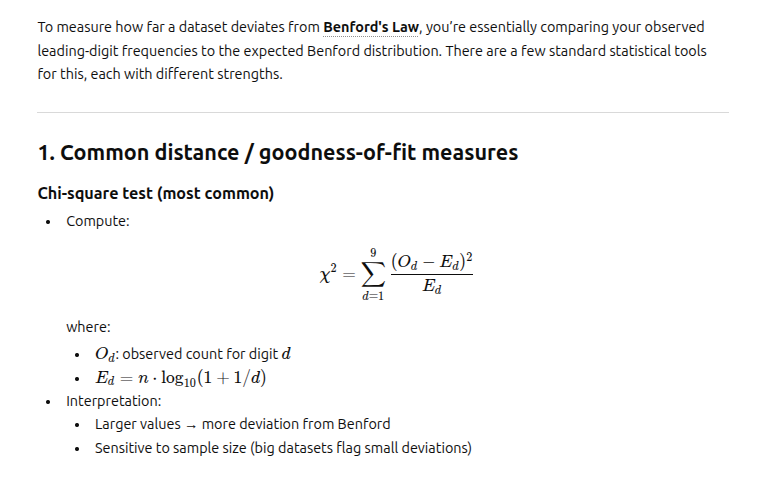

In [111]:
# Chi-square distance between values and expected distribution
chi2_estimado = 0
chi2_homologado = 0

for i in range(9):
  got = digit_counts_estimado.get(i+1, 0)
  exp = ideal_benford[i]*total_estimados
  chi2_estimado += (got -exp)**2/ideal_benford[i]
  print(str(got) +"vs"+str(exp))
print(chi2_estimado)

for i in range(9):
  got = digit_counts_homologado.get(i+1, 0)
  exp = ideal_benford[i]*total_homologados
  chi2_homologado += (got -exp)**2/ideal_benford[i]
  print(str(got) +"vs"+str(exp))
print(chi2_homologado)


16vs14.147
6vs8.272
6vs5.875
5vs4.559
3vs3.713
6vs3.149
3vs2.726
1vs2.397
1vs2.162
239.5326230126463
11vs7.5249999999999995
3vs4.3999999999999995
3vs3.125
1vs2.4250000000000003
0vs1.975
4vs1.675
1vs1.4500000000000002
2vs1.275
0vs1.15
244.91771947722486


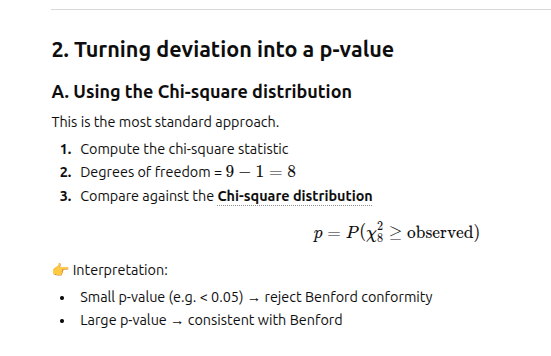

In [112]:
#values from chi² table for 9 - 1 = 8 degrees of freedom
chi2_5_percent = 15.507
chi2_1_percent = 20.090

reject_null_hipothesis = chi2_estimado > chi2_5_percent
message = "Reject null hypothesis" if reject_null_hipothesis else "Fail to reject null hypothesis"
print("Estimado: "+message)

reject_null_hipothesis = chi2_homologado > chi2_5_percent
message = "Reject null hypothesis" if reject_null_hipothesis else "Fail to reject null hypothesis"
print("Homologado: "+message)

Estimado: Reject null hypothesis
Homologado: Reject null hypothesis
